In [4]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
from langchain_groq import ChatGroq
import os

In [5]:
load_dotenv()

True

In [6]:
load_dotenv()

model = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0
)

In [7]:
class LLM_call(TypedDict):
    question: str
    answer: str


In [12]:
def Replier(state: LLM_call) -> LLM_call:
    ques = state["question"]

    prompt = f"Answer this question - {ques}"

    answer = model.invoke(prompt).content

    state["answer"] = answer

    return {'answer': answer}

In [13]:
graph = StateGraph(LLM_call)

graph.add_node("LLM_reply",Replier)

graph.add_edge(START,"LLM_reply")
graph.add_edge('LLM_reply',END)

workflow = graph.compile()

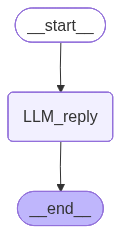

In [16]:
workflow

In [14]:
inistial_state = {'question':'What is color of mango?'}
final_state= workflow.invoke(inistial_state)
print(final_state)

{'question': 'What is color of mango?', 'answer': 'The color of a mango can vary depending on the ripeness and variety of the fruit. \n\n- Unripe mangoes are typically green.\n- Ripe mangoes can be yellow, orange, red, or a combination of these colors, often with a reddish or yellowish tint.\n- Some varieties, like the Haden or Tommy Atkins mango, have a yellow skin with a red blush.\n- Other varieties, like the Alphonso or Ataulfo mango, have a yellow skin with a golden or orange tint.\n\nSo, the color of a mango can range from green to yellow, orange, red, or a combination of these colors.'}


In [15]:
final_state

{'question': 'What is color of mango?',
 'answer': 'The color of a mango can vary depending on the ripeness and variety of the fruit. \n\n- Unripe mangoes are typically green.\n- Ripe mangoes can be yellow, orange, red, or a combination of these colors, often with a reddish or yellowish tint.\n- Some varieties, like the Haden or Tommy Atkins mango, have a yellow skin with a red blush.\n- Other varieties, like the Alphonso or Ataulfo mango, have a yellow skin with a golden or orange tint.\n\nSo, the color of a mango can range from green to yellow, orange, red, or a combination of these colors.'}